# Connected 2D Synthetic Realizations (`phi = 0.40`) with Pore-Network Statistics and `Kx`

Objective:
- generate 30 connected **2D synthetic** porous-media realizations at target porosity `phi=0.40`
- extract one pore network per realization
- characterize:
  - pore size distribution (PSD)
  - throat size distribution
  - coordination number distribution
- estimate absolute permeability in the x-direction (`Kx`) for each realization
- plot the `Kx` distribution over all realizations

Scientific notes:
- The default generator is a multiscale PoreSpy blobs field thresholded back to
  the requested porosity, which is more flexible than single-scale blobs while
  remaining fully synthetic.
- 2D percolation at `phi=0.40` can still fail for some random seeds, so this
  notebook uses a retry loop and keeps accepted (x-spanning) realizations only.
- This workflow remains synthetic; it is useful for sensitivity and Monte Carlo
  studies, but it is not a direct reconstruction of a specific rock.


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover
    _tqdm = None

from voids.generators import (
    generate_spanning_blobs_matrix,
    generate_spanning_multiscale_blobs_matrix,
)
from voids.image import extract_spanning_pore_network
from voids.geom import characteristic_size
from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)

/Users/dtvolpatto/Work/voids/.pixi/envs/lbm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def iter_progress(iterable, *, desc: str, enabled: bool = True):
    if enabled and _tqdm is not None:
        return _tqdm(iterable, desc=desc, dynamic_ncols=True, leave=False)
    return iterable

In [3]:
# Study controls (2D synthetic)
N_REALIZATIONS = 50
TARGET_POROSITY = 0.40

# Image shape in voxels. For a fixed configuration and BASE_SEED, the accepted
# realizations remain reproducible across runs.
SHAPE_2D = (512, 512)  # (nx, ny)
FLOW_AXIS = "x"
FLOW_AXIS_INDEX = 0
VOXEL_SIZE_M = 10.0e-6

GENERATOR_NAME = "multiscale_blobs"  # "multiscale_blobs" or "blobs"

# Single-scale blobs control
BLOBINESS = 0.8

# Multiscale blobs controls
MULTISCALE_BLOBINESS_PRIMARY = (0.8, 1.2)
MULTISCALE_BLOBINESS_SECONDARY = (2.5, 6.0)
MULTISCALE_PRIMARY_WEIGHT = 0.75

BASE_SEED = 20260408
ATTEMPT_BUDGET_MULTIPLIER = 20

USE_TQDM = True
N_PREVIEW_IMAGES = 6

fluid = FluidSinglePhase(viscosity=1.0e-3)
bc = PressureBC("inlet_xmin", "outlet_xmax", pin=2.0e5, pout=1.0e5)
solve_options = SinglePhaseOptions(conductance_model="valvatne_blunt", solver="direct")

print("N realizations:", N_REALIZATIONS)
print("Target porosity:", TARGET_POROSITY)
print("Shape:", SHAPE_2D)
print("Flow axis:", FLOW_AXIS)
print("Generator:", GENERATOR_NAME)
print("Base seed:", BASE_SEED)
if GENERATOR_NAME == "blobs":
    print("Blobiness:", BLOBINESS)
elif GENERATOR_NAME == "multiscale_blobs":
    print("Primary blobiness:", MULTISCALE_BLOBINESS_PRIMARY)
    print("Secondary blobiness:", MULTISCALE_BLOBINESS_SECONDARY)
    print("Primary weight:", MULTISCALE_PRIMARY_WEIGHT)
else:
    raise ValueError(f"Unsupported GENERATOR_NAME: {GENERATOR_NAME}")
max_total_attempts = max(
    int(N_REALIZATIONS * ATTEMPT_BUDGET_MULTIPLIER), int(N_REALIZATIONS)
)
print("Attempt budget:", max_total_attempts)
print(
    "Image reproducibility rule: for this exact configuration, the notebook scans "
    "the same seed stream starting at BASE_SEED and keeps the first successful realizations."
)

N realizations: 50
Target porosity: 0.4
Shape: (512, 512)
Flow axis: x
Generator: multiscale_blobs
Base seed: 20260408
Primary blobiness: (0.8, 1.2)
Secondary blobiness: (2.5, 6.0)
Primary weight: 0.75
Attempt budget: 1000
Image reproducibility rule: for this exact configuration, the notebook scans the same seed stream starting at BASE_SEED and keeps the first successful realizations.


In [4]:
rows: list[dict[str, float | int | str]] = []
payloads: list[dict[str, object]] = []
preview_images: list[tuple[int, np.ndarray]] = []
failures: list[dict[str, object]] = []
accepted_seed_starts: list[int] = []
seed_schedule = [BASE_SEED + attempt for attempt in range(max_total_attempts)]

for loop_id, seed_start in enumerate(
    iter_progress(seed_schedule, desc="Generating 2D realizations", enabled=USE_TQDM),
    start=1,
):
    if len(rows) >= N_REALIZATIONS:
        break

    realization_id = len(rows) + 1

    try:
        if GENERATOR_NAME == "blobs":
            binary_void, seed_used = generate_spanning_blobs_matrix(
                shape=SHAPE_2D,
                porosity=TARGET_POROSITY,
                blobiness=BLOBINESS,
                axis_index=FLOW_AXIS_INDEX,
                seed_start=seed_start,
                max_tries=1,
            )
        elif GENERATOR_NAME == "multiscale_blobs":
            binary_void, seed_used = generate_spanning_multiscale_blobs_matrix(
                shape=SHAPE_2D,
                porosity=TARGET_POROSITY,
                blobiness_primary=MULTISCALE_BLOBINESS_PRIMARY,
                blobiness_secondary=MULTISCALE_BLOBINESS_SECONDARY,
                primary_weight=MULTISCALE_PRIMARY_WEIGHT,
                axis_index=FLOW_AXIS_INDEX,
                seed_start=seed_start,
                max_tries=1,
            )
        else:  # pragma: no cover - guarded above
            raise ValueError(f"Unsupported GENERATOR_NAME: {GENERATOR_NAME}")

        extract = extract_spanning_pore_network(
            binary_void.astype(int),
            voxel_size=VOXEL_SIZE_M,
            flow_axis=FLOW_AXIS,
            length_unit="m",
            provenance_notes={
                "study": "connected_porous_media_2d_blobs_phi040",
                "realization": realization_id,
                "generator_name": GENERATOR_NAME,
                "seed_start": int(seed_start),
                "seed_used": int(seed_used),
                "target_porosity": TARGET_POROSITY,
                "blobiness": BLOBINESS if GENERATOR_NAME == "blobs" else None,
                "blobiness_primary": (
                    list(MULTISCALE_BLOBINESS_PRIMARY)
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
                "blobiness_secondary": (
                    list(MULTISCALE_BLOBINESS_SECONDARY)
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
                "primary_weight": (
                    MULTISCALE_PRIMARY_WEIGHT
                    if GENERATOR_NAME == "multiscale_blobs"
                    else None
                ),
            },
        )
        net = extract.net

        res = solve(net, fluid=fluid, bc=bc, axis=FLOW_AXIS, options=solve_options)
        kx = float(res.permeability[FLOW_AXIS])

        pore_size_m, pore_field = characteristic_size(
            net.pore, expected_shape=(net.Np,)
        )
        throat_size_m, throat_field = characteristic_size(
            net.throat, expected_shape=(net.Nt,)
        )
        pore_size_um = 1.0e6 * pore_size_m
        throat_size_um = 1.0e6 * throat_size_m
        coordination = coordination_numbers(net).astype(int)

        phi_image = float(binary_void.mean())
        phi_abs = float(absolute_porosity(net))
        phi_eff_x = float(effective_porosity(net, axis=FLOW_AXIS))

        rows.append(
            {
                "realization": realization_id,
                "seed_start": int(seed_start),
                "seed_used": int(seed_used),
                "phi_image": phi_image,
                "phi_abs_network": phi_abs,
                "phi_eff_x_network": phi_eff_x,
                "Np": int(net.Np),
                "Nt": int(net.Nt),
                "pore_size_field": pore_field,
                "throat_size_field": throat_field,
                "pore_size_mean_um": float(np.mean(pore_size_um)),
                "pore_size_p50_um": float(np.median(pore_size_um)),
                "throat_size_mean_um": float(np.mean(throat_size_um)),
                "throat_size_p50_um": float(np.median(throat_size_um)),
                "coordination_mean": float(np.mean(coordination)),
                "kabs_x_m2": kx,
                "mass_balance_error": float(res.mass_balance_error),
            }
        )
        payloads.append(
            {
                "realization": realization_id,
                "binary_void": binary_void,
                "pore_size_um": pore_size_um,
                "throat_size_um": throat_size_um,
                "coordination": coordination,
            }
        )

        if len(preview_images) < N_PREVIEW_IMAGES:
            preview_images.append((realization_id, binary_void))
        accepted_seed_starts.append(int(seed_start))
    except Exception as exc:
        failures.append(
            {"attempt": loop_id, "seed_start": seed_start, "error": str(exc)}
        )
        continue

if len(rows) < N_REALIZATIONS:
    raise RuntimeError(
        f"Collected {len(rows)} successful realizations out of {N_REALIZATIONS} requested "
        f"after {len(seed_schedule)} attempts. For the same configuration, increasing "
        "ATTEMPT_BUDGET_MULTIPLIER preserves reproducibility because the seed stream stays fixed."
    )

summary_df = pd.DataFrame(rows).sort_values("realization").reset_index(drop=True)
summary_df

Generating 2D realizations:   1%|          | 12/1000 [00:00<01:15, 13.16it/s]OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,realization,seed_start,seed_used,phi_image,phi_abs_network,phi_eff_x_network,Np,Nt,pore_size_field,throat_size_field,pore_size_mean_um,pore_size_p50_um,throat_size_mean_um,throat_size_p50_um,coordination_mean,kabs_x_m2,mass_balance_error
0,1,20260420,20260420,0.400002,0.143871,0.143871,41,40,diameter_equivalent,diameter_equivalent,278.744789,232.347491,45.520475,49.823779,1.951220,7.204194e-18,1.359682e-19
1,2,20260426,20260426,0.400002,0.230049,0.230049,81,92,diameter_equivalent,diameter_equivalent,264.434021,235.342134,44.388479,43.701937,2.271605,3.276158e-15,1.740658e-18
2,3,20260427,20260427,0.400002,0.198177,0.198177,46,50,diameter_equivalent,diameter_equivalent,306.242949,236.504949,48.736435,52.911997,2.173913,1.478324e-17,1.722240e-19
3,4,20260452,20260452,0.400002,0.197124,0.197124,64,73,diameter_equivalent,diameter_equivalent,262.669407,173.883249,37.620308,33.851375,2.281250,3.423711e-16,5.374795e-19
4,5,20260453,20260453,0.400002,0.309559,0.309559,87,92,diameter_equivalent,diameter_equivalent,290.736963,263.180986,41.794343,39.886245,2.114943,6.962352e-16,1.409560e-19
5,6,20260456,20260456,0.400002,0.119995,0.119995,62,68,diameter_equivalent,diameter_equivalent,199.513212,141.834352,41.350833,37.424103,2.193548,5.486081e-17,1.332892e-19
6,7,20260457,20260457,0.400002,0.191929,0.191929,56,62,diameter_equivalent,diameter_equivalent,281.828675,230.594397,41.935595,42.220082,2.214286,1.461616e-15,1.203667e-19
7,8,20260460,20260460,0.400002,0.339294,0.339294,92,102,diameter_equivalent,diameter_equivalent,288.161458,236.333282,41.445504,39.088201,2.217391,3.003615e-16,9.575114e-20
8,9,20260463,20260463,0.400005,0.329365,0.329365,92,104,diameter_equivalent,diameter_equivalent,271.165800,168.690792,40.753425,39.088201,2.260870,8.148764e-17,1.225301e-19
9,10,20260467,20260467,0.400005,0.145901,0.145901,37,42,diameter_equivalent,diameter_equivalent,300.699214,274.314522,38.268224,34.669743,2.270270,1.059142e-16,4.780209e-20


In [5]:
print("Successful realizations:", len(summary_df))
print("Accepted seed starts:")
print(accepted_seed_starts)
print("Failed attempts:", len(failures))
print("First 5 failures (if any):")
for item in failures[:5]:
    print(item)

summary_stats = summary_df[
    [
        "phi_image",
        "phi_abs_network",
        "phi_eff_x_network",
        "Np",
        "Nt",
        "pore_size_mean_um",
        "throat_size_mean_um",
        "coordination_mean",
        "kabs_x_m2",
        "mass_balance_error",
    ]
].describe(percentiles=[0.1, 0.5, 0.9])
summary_stats

Successful realizations: 50
Accepted seed starts:
[20260420, 20260426, 20260427, 20260452, 20260453, 20260456, 20260457, 20260460, 20260463, 20260467, 20260468, 20260471, 20260472, 20260474, 20260487, 20260489, 20260490, 20260491, 20260493, 20260494, 20260495, 20260507, 20260515, 20260523, 20260527, 20260528, 20260529, 20260532, 20260535, 20260536, 20260537, 20260548, 20260556, 20260569, 20260571, 20260572, 20260588, 20260603, 20260619, 20260621, 20260624, 20260628, 20260630, 20260632, 20260646, 20260648, 20260654, 20260656, 20260668, 20260674]
Failed attempts: 217
First 5 failures (if any):
{'attempt': 1, 'seed_start': 20260408, 'error': 'Could not generate spanning multiscale blobs matrix for seed_start=20260408 after 1 trials'}
{'attempt': 2, 'seed_start': 20260409, 'error': 'Could not generate spanning multiscale blobs matrix for seed_start=20260409 after 1 trials'}
{'attempt': 3, 'seed_start': 20260410, 'error': 'Could not generate spanning multiscale blobs matrix for seed_start=2

,phi_image,phi_abs_network,phi_eff_x_network,Np,Nt,pore_size_mean_um,throat_size_mean_um,coordination_mean,kabs_x_m2,mass_balance_error
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,5.000000e+01
mean,0.400002,0.203931,0.203931,57.640000,62.620000,282.974024,42.222547,2.168124,1.128333e-15,2.073839e-19
std,0.000001,0.056971,0.056971,16.564974,18.561415,27.132225,3.479538,0.095006,2.945147e-15,3.082212e-19
min,0.400002,0.116524,0.116524,33.000000,33.000000,199.513212,34.997536,1.951220,5.642247e-18,1.816228e-20
10%,0.400002,0.144699,0.144699,38.900000,41.900000,257.899305,37.591200,2.032727,1.077408e-17,5.228503e-20
50%,0.400002,0.196281,0.196281,56.000000,61.000000,282.117520,41.968009,2.163333,1.477336e-16,1.214484e-19
90%,0.400002,0.281056,0.281056,83.000000,90.200000,317.558877,46.372056,2.280757,1.803780e-15,4.335040e-19
max,0.400005,0.339294,0.339294,92.000000,104.000000,340.712894,49.499709,2.400000,1.486949e-14,1.740658e-18


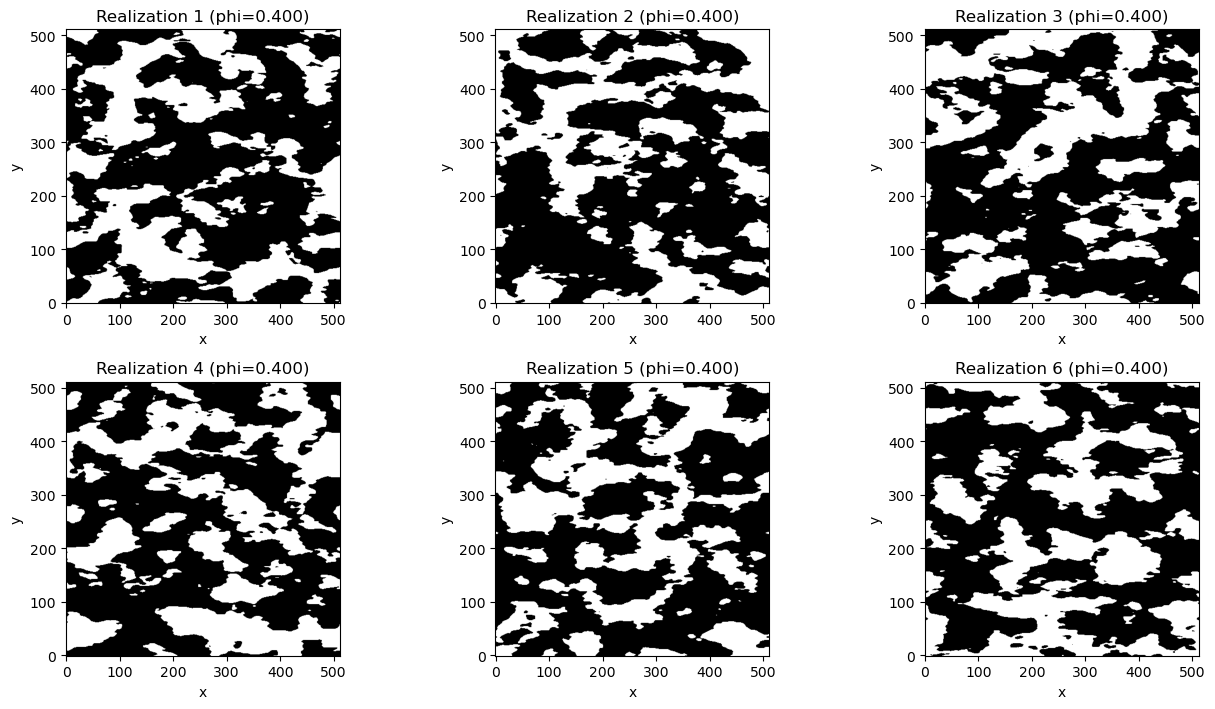

In [6]:
# Visualize a subset of binary realizations (void=True shown in white).
n_show = min(len(preview_images), N_PREVIEW_IMAGES)
n_cols = 3
n_rows = int(np.ceil(n_show / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.6 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax in axes:
    ax.axis("off")

for ax, (rid, img) in zip(axes, preview_images):
    ax.imshow(img.T, cmap="gray", origin="lower")
    ax.set_title(f"Realization {rid} (phi={img.mean():.3f})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("on")

plt.tight_layout()
plt.show()

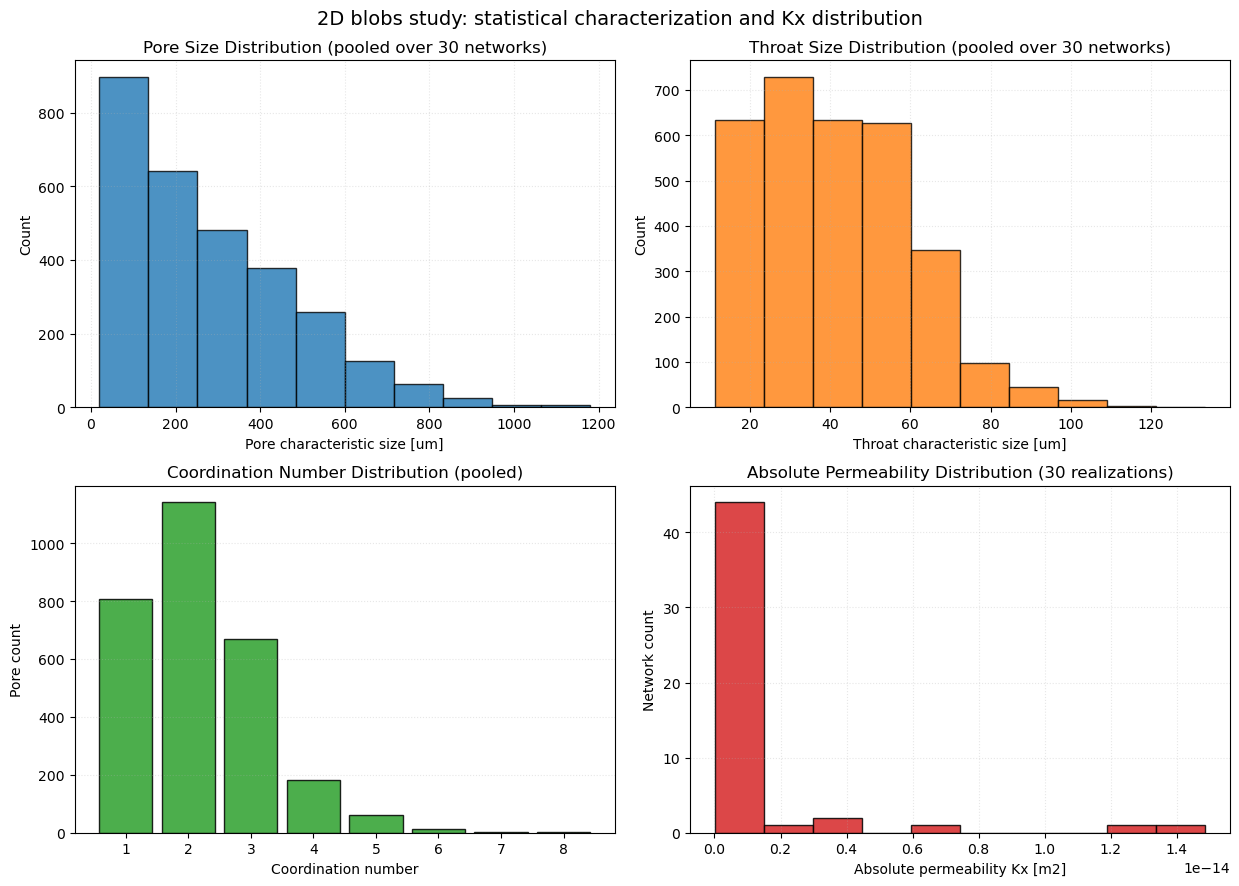

In [7]:
# Aggregate distributions over all extracted networks.
all_pore_sizes_um = np.concatenate([p["pore_size_um"] for p in payloads])
all_throat_sizes_um = np.concatenate([p["throat_size_um"] for p in payloads])
all_coordination = np.concatenate([p["coordination"] for p in payloads]).astype(int)
all_kx = summary_df["kabs_x_m2"].to_numpy(dtype=float)

coord_vals, coord_counts = np.unique(all_coordination, return_counts=True)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))

axes[0, 0].hist(all_pore_sizes_um, color="tab:blue", edgecolor="black", alpha=0.8)
axes[0, 0].set_xlabel("Pore characteristic size [um]")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Pore Size Distribution (pooled over 30 networks)")
axes[0, 0].grid(alpha=0.3, linestyle=":")

axes[0, 1].hist(
    all_throat_sizes_um,
    color="tab:orange",
    edgecolor="black",
    alpha=0.8,
)
axes[0, 1].set_xlabel("Throat characteristic size [um]")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Throat Size Distribution (pooled over 30 networks)")
axes[0, 1].grid(alpha=0.3, linestyle=":")

axes[1, 0].bar(
    coord_vals,
    coord_counts,
    width=0.85,
    color="tab:green",
    edgecolor="black",
    alpha=0.85,
)
axes[1, 0].set_xlabel("Coordination number")
axes[1, 0].set_ylabel("Pore count")
axes[1, 0].set_title("Coordination Number Distribution (pooled)")
axes[1, 0].grid(alpha=0.3, linestyle=":", axis="y")

axes[1, 1].hist(all_kx, color="tab:red", edgecolor="black", alpha=0.85)
axes[1, 1].set_xlabel("Absolute permeability Kx [m2]")
axes[1, 1].set_ylabel("Network count")
axes[1, 1].set_title("Absolute Permeability Distribution (30 realizations)")
axes[1, 1].grid(alpha=0.3, linestyle=":")

fig.suptitle(
    "2D blobs study: statistical characterization and Kx distribution", fontsize=14
)
plt.tight_layout()
plt.show()

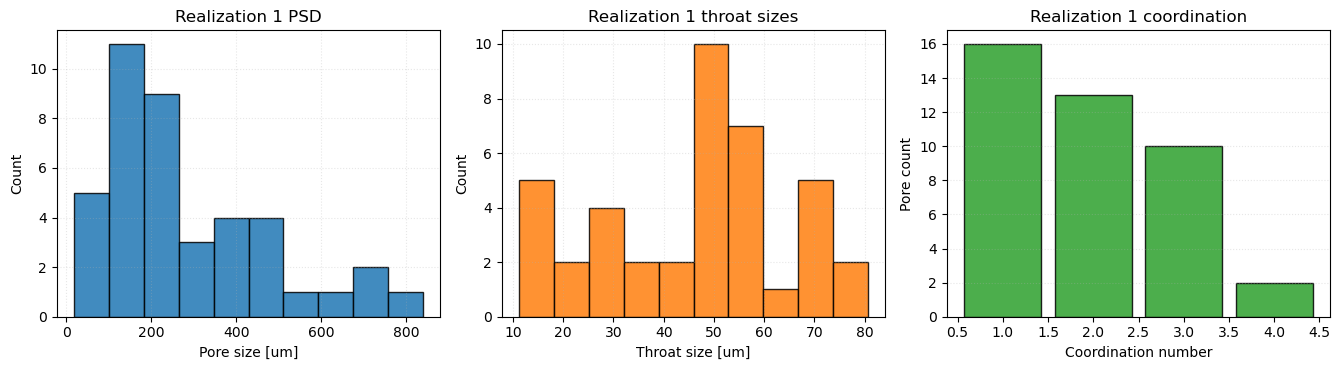

In [8]:
# Optional: inspect one specific realization in detail.
def plot_single_realization_distributions(realization: int) -> None:
    item = next(p for p in payloads if int(p["realization"]) == int(realization))
    pore_size_um = np.asarray(item["pore_size_um"], dtype=float)
    throat_size_um = np.asarray(item["throat_size_um"], dtype=float)
    coordination = np.asarray(item["coordination"], dtype=int)
    coord_vals_local, coord_counts_local = np.unique(coordination, return_counts=True)

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
    axes[0].hist(pore_size_um, color="tab:blue", edgecolor="black", alpha=0.85)
    axes[0].set_title(f"Realization {realization} PSD")
    axes[0].set_xlabel("Pore size [um]")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3, linestyle=":")

    axes[1].hist(throat_size_um, color="tab:orange", edgecolor="black", alpha=0.85)
    axes[1].set_title(f"Realization {realization} throat sizes")
    axes[1].set_xlabel("Throat size [um]")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3, linestyle=":")

    axes[2].bar(
        coord_vals_local,
        coord_counts_local,
        width=0.85,
        color="tab:green",
        edgecolor="black",
        alpha=0.85,
    )
    axes[2].set_title(f"Realization {realization} coordination")
    axes[2].set_xlabel("Coordination number")
    axes[2].set_ylabel("Pore count")
    axes[2].grid(alpha=0.3, linestyle=":", axis="y")

    plt.tight_layout()
    plt.show()


plot_single_realization_distributions(realization=1)

## Assumptions and possible weak points

1. We assume `blobs` at this resolution and `blobiness=0.8` is a useful synthetic proxy.
   The default multiscale blobs setting is more flexible than single-scale blobs, but it can still
   be incorrect for rocks with sharper grain boundaries or nonstationary texture.
2. At `phi=0.40` in 2D, x-spanning acceptance depends on random seed and domain aspect ratio.
   If your scientific objective is unbiased morphology sampling, conditioning on x-spanning can bias the ensemble.
3. Permeability here is network-model permeability from extracted geometry (`snow2` + conduit model),
   not direct DNS on the voxel grid; extraction/model choices can shift `Kx` distributions.
4. Some 2D extracted networks can have low pore counts; if richer distributions are needed,
   increase image size and/or run sensitivity tests over extraction parameters.